<a href="https://colab.research.google.com/github/Harshini09-design/Mini-Project-/blob/main/Mini%20Project%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PLEASE UPLOAD archive (1).zip


Saving archive (1) (1).zip to archive (1) (1).zip

Uploaded: archive (1) (1).zip

ZIP FILE EXTRACTED SUCCESSFULLY

DATASET FILE:
healthcare_data/dataset.csv

ORIGINAL DATASET
Rows: 4920
Columns: 18

Columns:
['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

First 5 rows:
            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Sympt

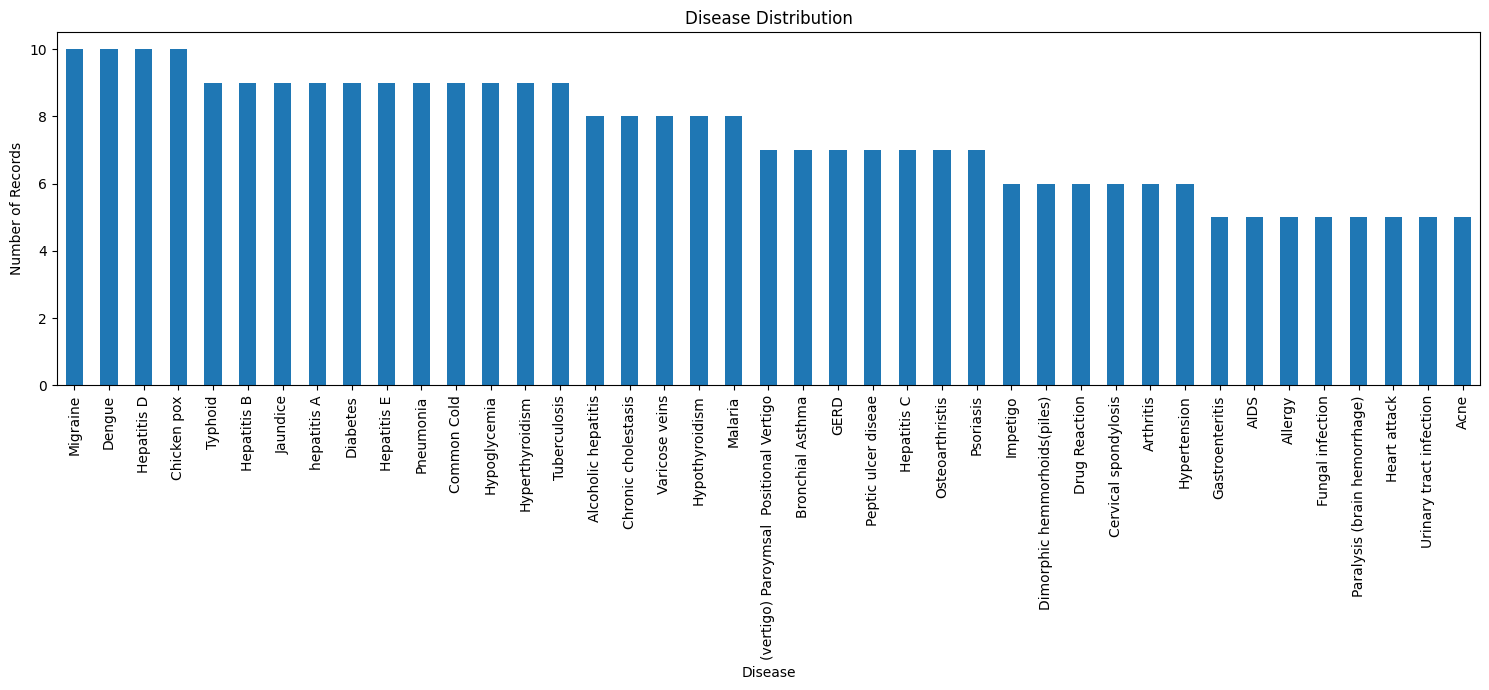


SYMPTOM COLUMNS
Number of symptom columns: 17

Symptom columns:
['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

SYMPTOMS
Total unique symptoms: 131

First 20 symptoms:
['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort', 'blister', 'blood_in_sputum', 'bloody_stool', 'blurred_and_distorted_vision', 'breathlessness', 'brittle_nails', 'bruising', 'burning_micturition', 'chest_pain', 'chills']


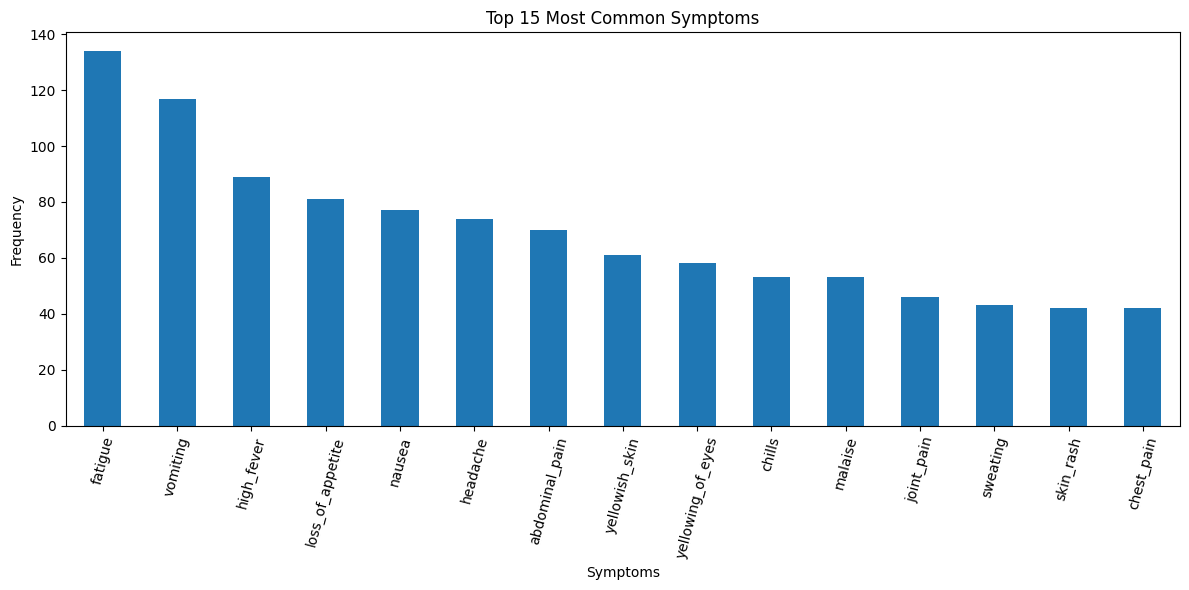


MACHINE LEARNING DATA
X rows: 304
Y rows: 304
X columns: 131

Number of disease classes: 41

Minimum records in a disease class:
5

TRAIN TEST SPLIT
Training samples: 243
Testing samples: 61

RANDOM FOREST
Random Forest Accuracy: 100.0 %

LOGISTIC REGRESSION
Logistic Regression Accuracy: 100.0 %


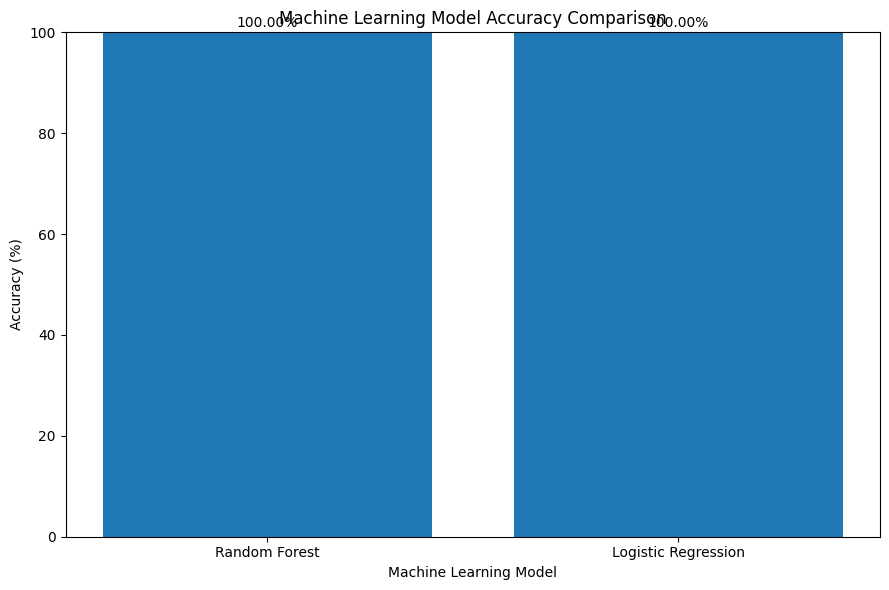


SELECTED MODEL
Model: Random Forest

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          16       1.

<Figure size 1200x1000 with 0 Axes>

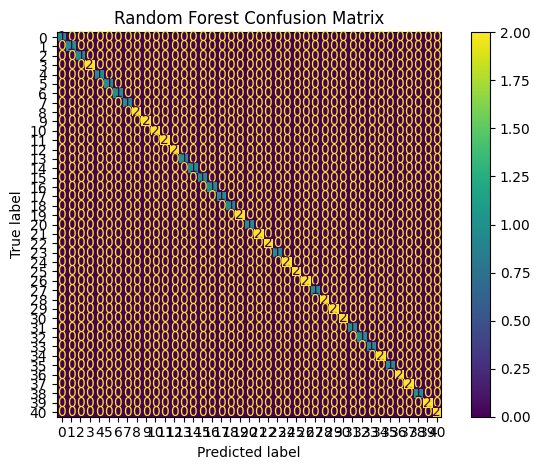


SAMPLE PREDICTION
Predicted Disease: Hepatitis B
Model Confidence: 72.0 %

PROJECT COMPLETED SUCCESSFULLY
Total records: 304
Total diseases: 41
Total symptoms: 131
Random Forest Accuracy: 100.0 %
Logistic Regression Accuracy: 100.0 %
Selected Model: Random Forest
Sample Prediction: Hepatitis B
Confidence: 72.0 %

Saved files:
disease_model.pkl
disease_encoder.pkl
features.pkl

Educational/Research Use Only.
This is not a medical diagnostic tool.


In [1]:
# ============================================================
# HEALTHCARE DISEASE PREDICTION
# COMPLETE CORRECTED VERSION
# ============================================================

import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. UPLOAD ZIP FILE
# ============================================================

print("PLEASE UPLOAD archive (1).zip")

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

print("\nUploaded:", zip_file)


# ============================================================
# 2. EXTRACT ZIP
# ============================================================

extract_folder = "healthcare_data"

os.makedirs(
    extract_folder,
    exist_ok=True
)

with zipfile.ZipFile(
    zip_file,
    "r"
) as zip_ref:

    zip_ref.extractall(
        extract_folder
    )

print("\nZIP FILE EXTRACTED SUCCESSFULLY")


# ============================================================
# 3. FIND CSV FILES
# ============================================================

dataset_path = None
severity_path = None
description_path = None
precaution_path = None

for root, folders, files_list in os.walk(
    extract_folder
):

    for file in files_list:

        file_lower = file.lower()

        full_path = os.path.join(
            root,
            file
        )

        if file_lower == "dataset.csv":

            dataset_path = full_path

        elif file_lower == "symptom-severity.csv":

            severity_path = full_path

        elif file_lower == "symptom_description.csv":

            description_path = full_path

        elif file_lower == "symptom_precaution.csv":

            precaution_path = full_path


print("\nDATASET FILE:")
print(dataset_path)


# ============================================================
# 4. CHECK DATASET
# ============================================================

if dataset_path is None:

    raise FileNotFoundError(
        "dataset.csv was not found inside the ZIP file."
    )


# ============================================================
# 5. LOAD DATASET
# ============================================================

data = pd.read_csv(
    dataset_path
)


# ============================================================
# 6. DISPLAY ORIGINAL DATA
# ============================================================

print("\n========================================")
print("ORIGINAL DATASET")
print("========================================")

print(
    "Rows:",
    data.shape[0]
)

print(
    "Columns:",
    data.shape[1]
)

print("\nColumns:")

print(
    data.columns.tolist()
)

print("\nFirst 5 rows:")

print(
    data.head()
)


# ============================================================
# 7. CLEAN COLUMN NAMES
# ============================================================

data.columns = (
    data.columns
    .astype(str)
    .str.strip()
)


# ============================================================
# 8. FIND DISEASE COLUMN AUTOMATICALLY
# ============================================================

disease_column = None

possible_names = [
    "disease",
    "Disease",
    "prognosis",
    "Prognosis",
    "target",
    "Target",
    "label",
    "Label"
]


for column in data.columns:

    if column.strip() in possible_names:

        disease_column = column

        break


# If Disease column was not found,
# check using lowercase names

if disease_column is None:

    for column in data.columns:

        if column.lower().strip() in [
            "disease",
            "prognosis",
            "target",
            "label"
        ]:

            disease_column = column

            break


# ============================================================
# 9. CHECK DISEASE COLUMN
# ============================================================

if disease_column is None:

    print(
        "\nDisease column was not automatically found."
    )

    print(
        "Using the FIRST column as disease column."
    )

    disease_column = data.columns[0]


print(
    "\nDisease Column Found:",
    disease_column
)


# ============================================================
# 10. CLEAN ALL TEXT VALUES
# ============================================================

for column in data.columns:

    data[column] = data[column].apply(

        lambda x:

        x.strip()

        if isinstance(x, str)

        else x

    )


# ============================================================
# 11. REMOVE EMPTY DISEASE VALUES
# ============================================================

data[disease_column] = (
    data[disease_column]
    .fillna("")
    .astype(str)
    .str.strip()
)


print(
    "\nRows before removing empty disease:",
    len(data)
)


data = data[
    data[disease_column] != ""
]


print(
    "Rows after removing empty disease:",
    len(data)
)


# ============================================================
# 12. REMOVE DUPLICATES
# ============================================================

before_duplicates = len(data)

data = data.drop_duplicates()

after_duplicates = len(data)

print(
    "Duplicate rows removed:",
    before_duplicates - after_duplicates
)


# ============================================================
# 13. RESET INDEX
# ============================================================

data = data.reset_index(
    drop=True
)


# ============================================================
# 14. REPLACE MISSING VALUES
# ============================================================

data = data.fillna("")


# ============================================================
# 15. FINAL DATA CHECK
# ============================================================

print("\n========================================")
print("CLEANED DATASET")
print("========================================")

print(
    "Rows:",
    data.shape[0]
)

print(
    "Columns:",
    data.shape[1]
)

print(
    "Disease Column:",
    disease_column
)


# IMPORTANT CHECK

if len(data) < 10:

    raise ValueError(
        "Only a few rows remain after cleaning. "
        "The dataset or disease column is incorrect."
    )


# ============================================================
# 16. DISEASE DISTRIBUTION
# ============================================================

disease_counts = (
    data[disease_column]
    .value_counts()
)


print("\n========================================")
print("DISEASE INFORMATION")
print("========================================")

print(
    "Total Diseases:",
    len(disease_counts)
)

print("\nDisease Counts:")

print(
    disease_counts
)


# ============================================================
# 17. DISEASE DISTRIBUTION GRAPH
# ============================================================

plt.figure(
    figsize=(15, 7)
)

disease_counts.plot(
    kind="bar"
)

plt.title(
    "Disease Distribution"
)

plt.xlabel(
    "Disease"
)

plt.ylabel(
    "Number of Records"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()


# ============================================================
# 18. IDENTIFY SYMPTOM COLUMNS
# ============================================================

symptom_columns = [
    column
    for column in data.columns
    if column != disease_column
]


print("\n========================================")
print("SYMPTOM COLUMNS")
print("========================================")

print(
    "Number of symptom columns:",
    len(symptom_columns)
)

print("\nSymptom columns:")

print(
    symptom_columns
)


# ============================================================
# 19. CREATE UNIQUE SYMPTOM LIST
# ============================================================

symptoms = set()


for column in symptom_columns:

    for value in data[column]:

        if value != "":

            value = str(
                value
            ).strip()

            if value != "":

                symptoms.add(
                    value
                )


symptoms = sorted(
    symptoms
)


print("\n========================================")
print("SYMPTOMS")
print("========================================")

print(
    "Total unique symptoms:",
    len(symptoms)
)

print("\nFirst 20 symptoms:")

print(
    symptoms[:20]
)


# ============================================================
# 20. CREATE SYMPTOM FREQUENCY
# ============================================================

symptom_counts = {}


for symptom in symptoms:

    count = 0

    for column in symptom_columns:

        count += (
            data[column] == symptom
        ).sum()

    symptom_counts[
        symptom
    ] = count


symptom_series = (
    pd.Series(
        symptom_counts
    )
    .sort_values(
        ascending=False
    )
)


# ============================================================
# 21. TOP SYMPTOMS GRAPH
# ============================================================

top_symptoms = (
    symptom_series
    .head(15)
)


plt.figure(
    figsize=(12, 6)
)

top_symptoms.plot(
    kind="bar"
)

plt.title(
    "Top 15 Most Common Symptoms"
)

plt.xlabel(
    "Symptoms"
)

plt.ylabel(
    "Frequency"
)

plt.xticks(
    rotation=75
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. CREATE MACHINE LEARNING FEATURES
# ============================================================

X = pd.DataFrame(
    0,
    index=data.index,
    columns=symptoms
)


# ============================================================
# 23. CONVERT SYMPTOMS TO 0 AND 1
# ============================================================

for i in range(
    len(data)
):

    for column in symptom_columns:

        value = data.loc[
            i,
            column
        ]

        if value != "":

            value = str(
                value
            ).strip()

            if value in X.columns:

                X.loc[
                    i,
                    value
                ] = 1


# ============================================================
# 24. TARGET VARIABLE
# ============================================================

y = data[
    disease_column
].copy()


# ============================================================
# 25. CHECK X AND Y
# ============================================================

print("\n========================================")
print("MACHINE LEARNING DATA")
print("========================================")

print(
    "X rows:",
    len(X)
)

print(
    "Y rows:",
    len(y)
)

print(
    "X columns:",
    len(X.columns)
)


if len(X) != len(y):

    raise ValueError(
        "X and Y have different numbers of rows."
    )


# ============================================================
# 26. ENCODE DISEASE
# ============================================================

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(
    y
)


print(
    "\nNumber of disease classes:",
    len(
        encoder.classes_
    )
)


# ============================================================
# 27. CHECK CLASS COUNTS
# ============================================================

class_counts = pd.Series(
    y_encoded
).value_counts()


print("\nMinimum records in a disease class:")

print(
    class_counts.min()
)


# ============================================================
# 28. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.2,

    random_state=42,

    stratify=y_encoded

)


print("\n========================================")
print("TRAIN TEST SPLIT")
print("========================================")

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)


# ============================================================
# 29. RANDOM FOREST
# ============================================================

print("\n========================================")
print("RANDOM FOREST")
print("========================================")

rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)


rf.fit(
    X_train,
    y_train
)


rf_pred = rf.predict(
    X_test
)


rf_accuracy = accuracy_score(

    y_test,

    rf_pred

)


print(
    "Random Forest Accuracy:",
    round(
        rf_accuracy * 100,
        2
    ),
    "%"
)


# ============================================================
# 30. LOGISTIC REGRESSION
# ============================================================

print("\n========================================")
print("LOGISTIC REGRESSION")
print("========================================")

lr = LogisticRegression(

    max_iter=2000

)


lr.fit(
    X_train,
    y_train
)


lr_pred = lr.predict(
    X_test
)


lr_accuracy = accuracy_score(

    y_test,

    lr_pred

)


print(
    "Logistic Regression Accuracy:",
    round(
        lr_accuracy * 100,
        2
    ),
    "%"
)


# ============================================================
# 31. MODEL ACCURACY GRAPH
# ============================================================

model_names = [

    "Random Forest",

    "Logistic Regression"

]


model_accuracies = [

    rf_accuracy * 100,

    lr_accuracy * 100

]


plt.figure(
    figsize=(9, 6)
)


bars = plt.bar(

    model_names,

    model_accuracies

)


plt.title(
    "Machine Learning Model Accuracy Comparison"
)


plt.xlabel(
    "Machine Learning Model"
)


plt.ylabel(
    "Accuracy (%)"
)


plt.ylim(
    0,
    100
)


for bar, value in zip(

    bars,

    model_accuracies

):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 1,

        f"{value:.2f}%",

        ha="center"

    )


plt.tight_layout()

plt.show()


# ============================================================
# 32. SELECT BEST MODEL
# ============================================================

if rf_accuracy >= lr_accuracy:

    model = rf

    model_name = "Random Forest"

    final_prediction = rf_pred

else:

    model = lr

    model_name = "Logistic Regression"

    final_prediction = lr_pred


print("\n========================================")
print("SELECTED MODEL")
print("========================================")

print(
    "Model:",
    model_name
)


# ============================================================
# 33. CLASSIFICATION REPORT
# ============================================================

print("\n========================================")
print("CLASSIFICATION REPORT")
print("========================================")


print(

    classification_report(

        y_test,

        final_prediction,

        zero_division=0

    )

)


# ============================================================
# 34. CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(12, 10)
)


ConfusionMatrixDisplay.from_predictions(

    y_test,

    final_prediction

)


plt.title(

    model_name
    + " Confusion Matrix"

)


plt.tight_layout()

plt.show()


# ============================================================
# 35. SAMPLE PREDICTION
# ============================================================

sample = X_test.iloc[
    0:1
]


prediction = model.predict(
    sample
)


predicted_disease = (
    encoder
    .inverse_transform(
        prediction
    )[0]
)


# ============================================================
# 36. CONFIDENCE
# ============================================================

probabilities = (
    model
    .predict_proba(
        sample
    )[0]
)


confidence = (
    max(probabilities)
    * 100
)


# ============================================================
# 37. SHOW PREDICTION
# ============================================================

print("\n========================================")
print("SAMPLE PREDICTION")
print("========================================")

print(
    "Predicted Disease:",
    predicted_disease
)

print(
    "Model Confidence:",
    round(
        confidence,
        2
    ),
    "%"
)


# ============================================================
# 38. SAVE MODEL
# ============================================================

joblib.dump(

    model,

    "disease_model.pkl"

)


joblib.dump(

    encoder,

    "disease_encoder.pkl"

)


joblib.dump(

    list(X.columns),

    "features.pkl"

)


# ============================================================
# 39. FINAL SUMMARY
# ============================================================

print("\n========================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("========================================")

print(
    "Total records:",
    len(data)
)

print(
    "Total diseases:",
    len(
        encoder.classes_
    )
)

print(
    "Total symptoms:",
    len(symptoms)
)

print(
    "Random Forest Accuracy:",
    round(
        rf_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Logistic Regression Accuracy:",
    round(
        lr_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Selected Model:",
    model_name
)

print(
    "Sample Prediction:",
    predicted_disease
)

print(
    "Confidence:",
    round(
        confidence,
        2
    ),
    "%"
)

print("\nSaved files:")

print(
    "disease_model.pkl"
)

print(
    "disease_encoder.pkl"
)

print(
    "features.pkl"
)

print("\nEducational/Research Use Only.")
print("This is not a medical diagnostic tool.")